In [1]:
import pandas as pd 

df=pd.read_csv("COPD_100k_dataset.csv")

In [2]:
df.head()


,Age,BMI,Smoking_Pack_Years,FEV1_FVC_Ratio,FEV1_Percent_Predicted,Oxygen_Saturation_SpO2,mMRC_Scale,Exacerbations_History,Occupational_Exposure,Eosinophil_Count,DLCO_Level,AAT_Level,COPD_Diagnosis
0,45,28.1,15.9,0.674,69,92.9,4,3,1,376,47.8,83,1
1,42,20.3,9.7,0.675,80,98.6,3,3,0,419,64.0,209,1
2,69,23.0,10.4,0.832,89,98.5,2,5,1,512,50.9,168,0
3,74,23.3,7.3,0.768,80,90.8,3,4,0,331,84.4,136,1
4,62,27.2,13.8,0.671,67,89.9,0,0,0,662,57.0,101,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Age                     100000 non-null  int64  
 1   BMI                     100000 non-null  float64
 2   Smoking_Pack_Years      100000 non-null  float64
 3   FEV1_FVC_Ratio          100000 non-null  float64
 4   FEV1_Percent_Predicted  100000 non-null  int64  
 5   Oxygen_Saturation_SpO2  100000 non-null  float64
 6   mMRC_Scale              100000 non-null  int64  
 7   Exacerbations_History   100000 non-null  int64  
 8   Occupational_Exposure   100000 non-null  int64  
 9   Eosinophil_Count        100000 non-null  int64  
 10  DLCO_Level              100000 non-null  float64
 11  AAT_Level               100000 non-null  int64  
 12  COPD_Diagnosis          100000 non-null  int64  
dtypes: float64(5), int64(8)
memory usage: 9.9 MB


In [4]:
df.describe()

,Age,BMI,Smoking_Pack_Years,FEV1_FVC_Ratio,FEV1_Percent_Predicted,Oxygen_Saturation_SpO2,mMRC_Scale,Exacerbations_History,Occupational_Exposure,Eosinophil_Count,DLCO_Level,AAT_Level,COPD_Diagnosis
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,62.07936,24.004575,24.470192,0.699501,66.994940,93.878831,2.006180,2.512410,0.299720,422.519180,69.888837,165.463040,0.820500
std,12.92520,3.947435,22.958166,0.118118,24.460708,3.763996,1.423693,1.718836,0.458138,217.017186,14.719357,49.059243,0.383772
min,40.00000,15.000000,0.000000,0.350000,25.000000,82.000000,0.000000,0.000000,0.000000,50.000000,20.000000,80.000000,0.000000
25%,51.00000,21.300000,7.200000,0.617000,46.000000,91.300000,1.000000,1.000000,0.000000,234.000000,59.900000,124.000000,1.000000
50%,62.00000,24.000000,17.200000,0.699000,67.000000,94.000000,2.000000,3.000000,0.000000,421.000000,69.900000,165.000000,1.000000
75%,73.00000,26.700000,34.400000,0.782000,88.000000,96.700000,3.000000,4.000000,1.000000,611.000000,80.200000,209.000000,1.000000
max,84.00000,35.000000,100.000000,0.950000,109.000000,100.000000,4.000000,5.000000,1.000000,799.000000,100.000000,249.000000,1.000000


In [5]:
df.isnull()

,Age,BMI,Smoking_Pack_Years,FEV1_FVC_Ratio,FEV1_Percent_Predicted,Oxygen_Saturation_SpO2,mMRC_Scale,Exacerbations_History,Occupational_Exposure,Eosinophil_Count,DLCO_Level,AAT_Level,COPD_Diagnosis
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,False,False,False,False,False,False,False,False,False,False,False,False,False
99996,False,False,False,False,False,False,False,False,False,False,False,False,False
99997,False,False,False,False,False,False,False,False,False,False,False,False,False
99998,False,False,False,False,False,False,False,False,False,False,False,False,False


In [6]:
df["COPD_Diagnosis"].value_counts()

COPD_Diagnosis
1    82050
0    17950
Name: count, dtype: int64

here as we found that classes are imbalanced it will cause model to predict more 1 than 0 but we want a perfect balance so we will use class_weight=balanced

In [10]:
X=df.drop(columns=["COPD_Diagnosis"])
Y=df["COPD_Diagnosis"]

In [30]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,random_state=42,test_size=0.32,stratify=Y)

In [28]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


firstly see how the data is distributed using PCA on a graph of heaviest weights

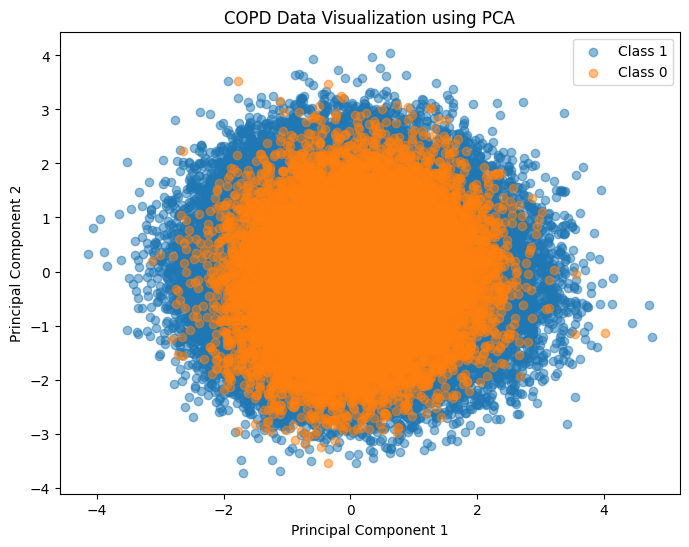

In [23]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaler.transform(X))

# Plot
plt.figure(figsize=(8,6))
y=Y
for label in y.unique():
    plt.scatter(
        X_pca[y == label, 0],
        X_pca[y == label, 1],
        label=f"Class {label}"
        ,alpha=0.5
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("COPD Data Visualization using PCA")
plt.legend()

plt.show()

we will take all the parameters using PCA (n_components =0.95) because when n_components =2 can not seprate outcomes properly 

In [31]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    oob_score=True,
    random_state=42
)

model.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [36]:
model.predict(X_test)

array([1, 0, 1, ..., 1, 1, 1], shape=(32000,))

In [40]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
import matplotlib.pyplot as plt
rf=model

# Predictions
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]  # probability for class 1

# 1️⃣ Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(Y_test, y_pred))

# 2️⃣ Full Classification Report
print("\nClassification Report:")
print(classification_report(Y_test, y_pred))

# 3️⃣ ROC-AUC Score
roc_score = roc_auc_score(Y_test, y_proba)
print("\nROC-AUC Score:", roc_score)

Confusion Matrix:
[[ 5153   591]
 [  160 26096]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.90      0.93      5744
           1       0.98      0.99      0.99     26256

    accuracy                           0.98     32000
   macro avg       0.97      0.95      0.96     32000
weighted avg       0.98      0.98      0.98     32000


ROC-AUC Score: 0.9973553498157842


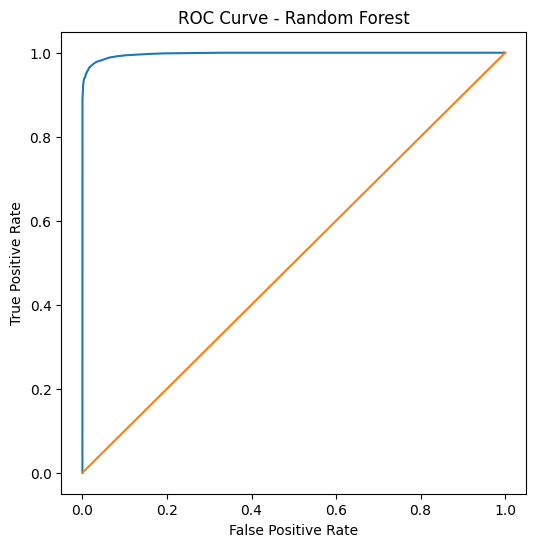

In [42]:
fpr, tpr, thresholds = roc_curve(Y_test, y_proba)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.show()